In [3]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

# Number of samples per class
n = 100

def generate_data(n, label):
    data = {
        'Age': np.random.randint(15, 40, n),
        'Matches_Played': np.random.randint(0, 21, n),
        'Training_Hours_Per_Week': np.random.randint(0, 21, n),
        'Past_Injuries': np.random.randint(0, 6, n),
        'Sleep_Hours_Per_Night': np.round(np.random.uniform(4, 9, n), 1),
        'Fitness_Test_Score': np.random.randint(30, 101, n),
        'Injury_Risk': [label] * n
    }
    return pd.DataFrame(data)

# Create balanced dataset
df_low = generate_data(n, 'Low')
df_med = generate_data(n, 'Medium')
df_high = generate_data(n, 'High')

df = pd.concat([df_low, df_med, df_high], ignore_index=True)

# Shuffle the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to Excel or CSV if needed
df.to_csv("balanced_injury_data.csv", index=False)

# Preview
print(df['Injury_Risk'].value_counts())
df.head()



Injury_Risk
High      100
Medium    100
Low       100
Name: count, dtype: int64


,Age,Matches_Played,Training_Hours_Per_Week,Past_Injuries,Sleep_Hours_Per_Night,Fitness_Test_Score,Injury_Risk
0,18,6,9,1,4.7,53,High
1,33,14,20,5,8.1,86,High
2,15,14,3,1,7.0,73,Medium
3,25,2,16,0,4.7,88,Low
4,23,1,5,2,5.2,66,High


In [4]:
df.tail()

,Age,Matches_Played,Training_Hours_Per_Week,Past_Injuries,Sleep_Hours_Per_Night,Fitness_Test_Score,Injury_Risk
295,28,7,13,0,8.2,91,Medium
296,24,8,15,4,7.3,87,Low
297,30,4,12,3,6.4,79,Medium
298,37,4,6,4,8.1,76,High
299,35,17,14,3,6.3,39,Medium


In [5]:
df['Injury_Risk'].value_counts()

Injury_Risk
High      100
Medium    100
Low       100
Name: count, dtype: int64

In [13]:
df.shape

(300, 8)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Player_ID                300 non-null    object 
 1   Age                      300 non-null    int32  
 2   Matches_Played           300 non-null    int32  
 3   Training_Hours_Per_Week  300 non-null    int32  
 4   Past_Injuries            300 non-null    int32  
 5   Sleep_Hours_Per_Night    300 non-null    float64
 6   Fitness_Test_Score       300 non-null    int32  
 7   Injury_Risk              300 non-null    object 
dtypes: float64(1), int32(5), object(2)
memory usage: 13.0+ KB


In [14]:
df.describe()

,Age,Matches_Played,Training_Hours_Per_Week,Past_Injuries,Sleep_Hours_Per_Night,Fitness_Test_Score
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,26.700000,7.666667,10.053333,2.600000,6.452000,64.676667
std,7.541413,4.855320,6.247179,1.744557,1.467791,20.507902
min,15.000000,0.000000,0.000000,0.000000,4.000000,30.000000
25%,20.000000,3.750000,4.000000,1.000000,5.200000,46.750000
50%,26.000000,7.500000,10.500000,3.000000,6.400000,64.500000
75%,34.000000,12.000000,16.000000,4.000000,7.700000,83.000000
max,39.000000,15.000000,20.000000,5.000000,9.000000,100.000000


<Axes: xlabel='Injury_Risk'>

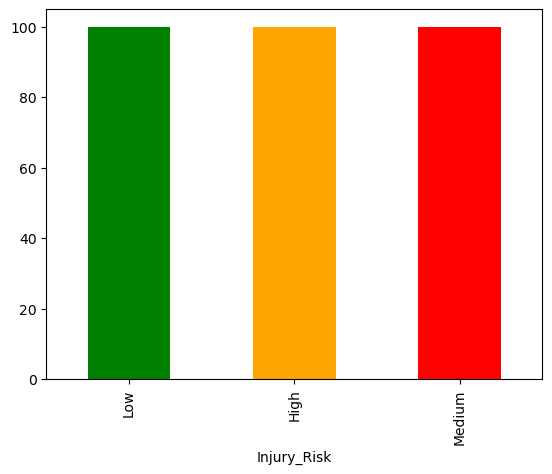

In [18]:
df['Injury_Risk'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])


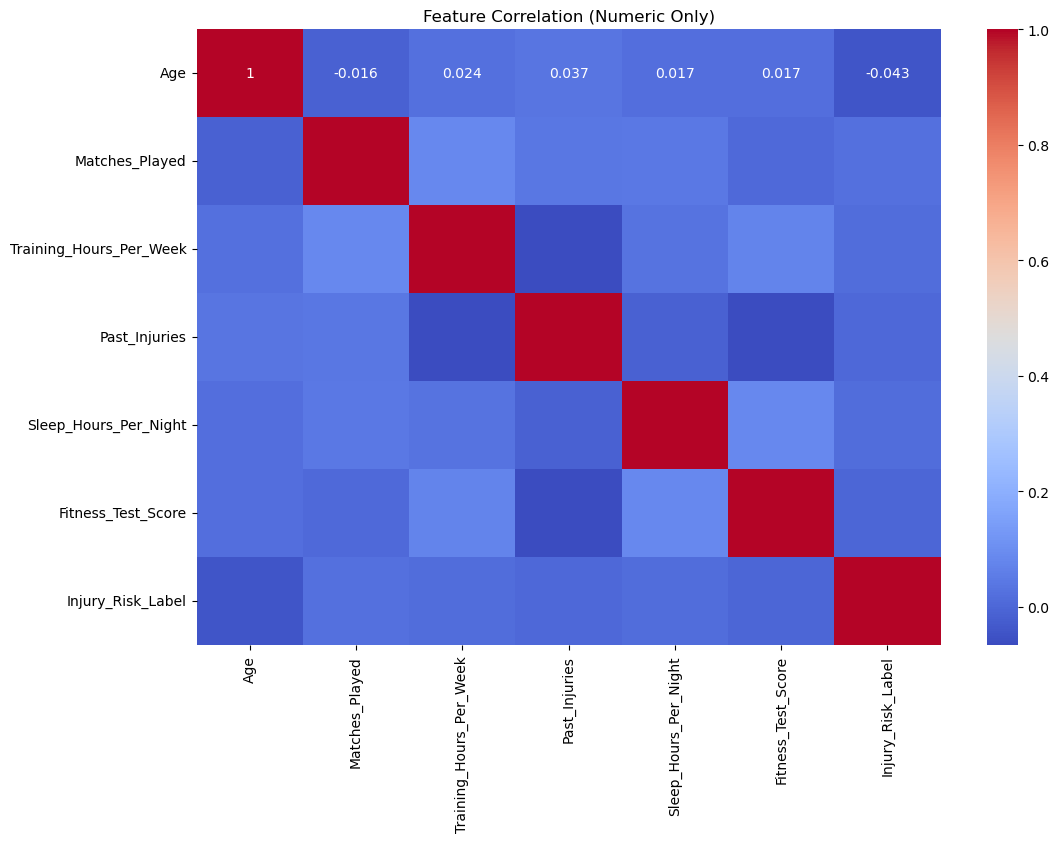

In [9]:
# Drop all non-numeric columns for correlation
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation (Numeric Only)')
plt.show()


In [15]:
from sklearn.preprocessing import LabelEncoder

# Create the encoder and fit to target
le = LabelEncoder()
df['Injury_Risk_Label'] = le.fit_transform(df['Injury_Risk'])

# Check how labels are mapped
label_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label Mapping:", label_mapping)


Label Mapping: {'High': 0, 'Low': 1, 'Medium': 2}


In [20]:
X = df.drop(['Injury_Risk', 'Injury_Risk_Label'], axis=1)
y = df['Injury_Risk_Label']

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42
)


In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize and train the model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred = dt_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Confusion Matrix:
 [[ 7  4  9]
 [ 7  6  7]
 [ 5 13  2]]

Classification Report:
               precision    recall  f1-score   support

        High       0.37      0.35      0.36        20
         Low       0.26      0.30      0.28        20
      Medium       0.11      0.10      0.11        20

    accuracy                           0.25        60
   macro avg       0.25      0.25      0.25        60
weighted avg       0.25      0.25      0.25        60



In [21]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
y_pred_rf = rf_model.predict(X_test)

# Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))


Confusion Matrix:
 [[6 5 9]
 [8 5 7]
 [7 9 4]]

Classification Report:
               precision    recall  f1-score   support

        High       0.29      0.30      0.29        20
         Low       0.26      0.25      0.26        20
      Medium       0.20      0.20      0.20        20

    accuracy                           0.25        60
   macro avg       0.25      0.25      0.25        60
weighted avg       0.25      0.25      0.25        60



In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))


Confusion Matrix:
 [[ 2  5 13]
 [ 4  8  8]
 [ 3  7 10]]

Classification Report:
               precision    recall  f1-score   support

        High       0.22      0.10      0.14        20
         Low       0.40      0.40      0.40        20
      Medium       0.32      0.50      0.39        20

    accuracy                           0.33        60
   macro avg       0.31      0.33      0.31        60
weighted avg       0.31      0.33      0.31        60



In [26]:
from sklearn.svm import SVC

model = SVC(kernel='rbf', class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [27]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
print("CV F1 Scores:", scores)
print("Average CV F1:", scores.mean())


CV F1 Scores: [0.27697442 0.28379028 0.23940621 0.30562924 0.23663724]
Average CV F1: 0.26848747624722963


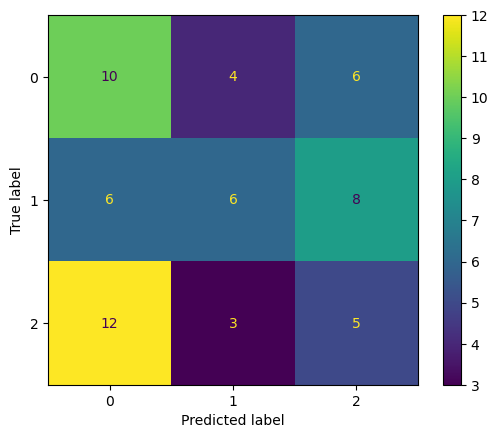

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)


In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(StandardScaler(), SVC(kernel='rbf', class_weight='balanced', random_state=42))
scores = cross_val_score(pipeline, X, y, cv=5, scoring='f1_macro')
print("CV F1 Scores (scaled):", scores)
print("Average CV F1 (scaled):", scores.mean())


CV F1 Scores (scaled): [0.33455433 0.26969112 0.34990235 0.31367538 0.39622096]
Average CV F1 (scaled): 0.3328088279819965


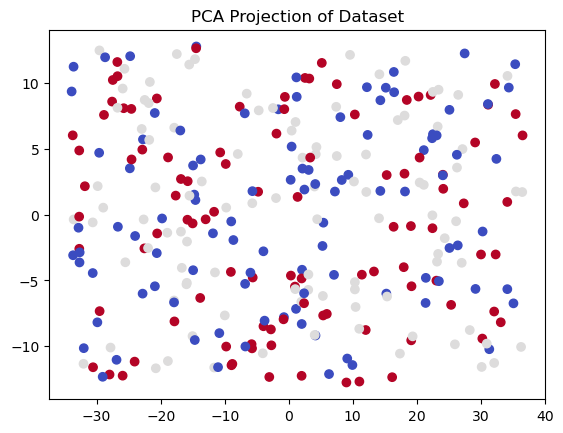

In [29]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='coolwarm')
plt.title("PCA Projection of Dataset")
plt.show()


In [30]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1_macro')
print("CV F1 Scores (XGB):", scores)
print("Average CV F1 (XGB):", scores.mean())


CV F1 Scores (XGB): [0.27697442 0.28379028 0.23940621 0.30562924 0.23663724]
Average CV F1 (XGB): 0.26848747624722963


In [31]:

!pip install xgboost --upgrade
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}




In [32]:
xgb = XGBClassifier(
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False
)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',   # We're optimizing for balanced performance
    cv=5,
    verbose=1,
    n_jobs=-1
)


In [35]:
grid.fit(X, y)


Fitting 5 folds for each of 54 candidates, totalling 270 fits


C:\Users\PMLS\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:04:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='mlogloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constrain...
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_class=3, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 5, 7], 'n_estimators': [50, 100, 150],
                         'subsample': [0.8, 1.0]},
             scoring='f1_macro', verbose=1)

In [36]:
print("Best Parameters:", grid.best_params_)
print("Best F1 Macro Score:", grid.best_score_)


Best Parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 150, 'subsample': 1.0}
Best F1 Macro Score: 0.3458301497513879


In [37]:
best_model = grid.best_estimator_

# Train on full training set if needed
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


C:\Users\PMLS\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [00:05:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.29      0.20      0.24        20
           1       0.35      0.35      0.35        20
           2       0.31      0.40      0.35        20

    accuracy                           0.32        60
   macro avg       0.31      0.32      0.31        60
weighted avg       0.31      0.32      0.31        60



In [38]:
import joblib
joblib.dump(model, "injury_risk_model.pkl")


['injury_risk_model.pkl']

In [39]:
import joblib

# Load the saved model
model = joblib.load('injury_risk_model.pkl')

# Ask user for input
print("🏋️ Athlete Injury Risk Predictor\n")

age = int(input("Enter Age (15–40): "))
matches = int(input("Enter Matches Played (0–20): "))
training = int(input("Enter Training Hours per Week (0–20): "))
injuries = int(input("Enter Number of Past Injuries (0–5): "))
sleep = float(input("Enter Sleep Hours per Night (4.0–9.0): "))
fitness = int(input("Enter Fitness Test Score (30–100): "))

# Format the input
athlete_data = [[age, matches, training, injuries, sleep, fitness]]

# Predict
prediction = model.predict(athlete_data)

# Show result
label_map = {0: 'High', 1: 'Low', 2: 'Medium'}
print("\nPredicted Injury Risk:", label_map[prediction[0]])



🏋️ Athlete Injury Risk Predictor



Enter Age (15–40):  18
Enter Matches Played (0–20):  45
Enter Training Hours per Week (0–20):  10
Enter Number of Past Injuries (0–5):  1
Enter Sleep Hours per Night (4.0–9.0):  6
Enter Fitness Test Score (30–100):  70



Predicted Injury Risk: Low


## import streamlit as st
import joblib

# Load model
model = joblib.load('injury_risk_model.pkl')

st.title("🏋️ Athlete Injury Risk Predictor")
st.write("Enter the athlete's details to predict injury risk level.")

# User inputs
age = st.slider("Age", 15, 40)
matches = st.slider("Matches Played", 0, 20)
training = st.slider("Training Hours/Week", 0, 20)
injuries = st.slider("Past Injuries", 0, 10, step=1)  # Adjust upper range if needed
sleep = st.slider("Sleep Hours/Night", 4.0, 9.0)
fitness = st.slider("Fitness Test Score", 30, 100)

if st.button("Predict Injury Risk"):
    data = [[age, matches, training, injuries, sleep, fitness]]
    pred = model.predict(data)
    risk_label = {0: 'High', 1: 'Low', 2: 'Medium'}
    st.success(f"🏷️ Predicted Injury Risk: **{risk_label[pred[0]]}**")
    st.write("Raw prediction label:", pred)

import streamlit as st
import joblib

# Load the full pipeline (includes StandardScaler + SVC)
pipeline = joblib.load("injury_risk_model.pkl")

st.title("🏋️ Athlete Injury Risk Predictor")
st.write("Enter the athlete's details to predict injury risk level.")

# Input sliders
age = st.slider("Age", 15, 40)
matches = st.slider("Matches Played", 0, 20)
training = st.slider("Training Hours/Week", 0, 20)
injuries = st.slider("Past Injuries", 0, 10, step=1)  # ✅ this was missing!
sleep = st.slider("Sleep Hours/Night", 4.0, 9.0)
fitness = st.slider("Fitness Test Score", 30, 100)

# Prediction logic
if st.button("Predict Injury Risk"):
    user_input = [[age, matches, training, injuries, sleep, fitness]]
    prediction = pipeline.predict(user_input)

    label_map = {0: "High", 1: "Low", 2: "Medium"}
    st.success(f"🏷️ Predicted Injury Risk: **{label_map[prediction[0]]}**")



In [40]:
pipeline = joblib.load("injury_risk_model.pkl")
